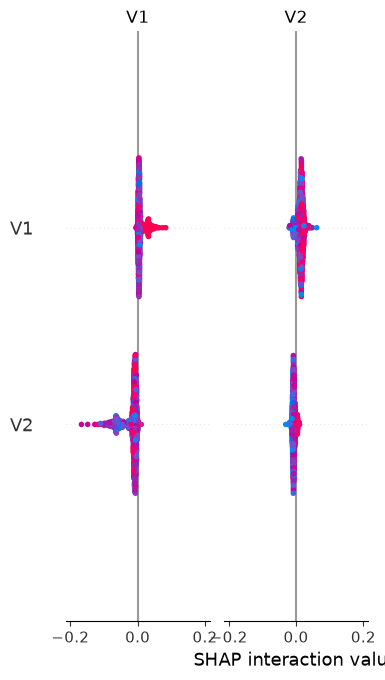

In [3]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from pathlib import Path

# In a Jupyter notebook, __file__ is not defined.
# Use the current working directory instead.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

for candidate in [project_root, *project_root.parents]:
    models_dir = candidate / "models"
    if models_dir.exists():
        project_root = candidate
        break
else:
    raise FileNotFoundError("Could not find project root containing models/.")

models_path = project_root / "models"
best_model = joblib.load(models_path / "random_forest.pkl")  # Load the Best Model

df = pd.read_csv(project_root / "data" / "creditcard_processed.csv")  # Load the Processed Dataset
X = df.drop("Class", axis=1)

X_sample = X.sample(1000, random_state=42)  # Sample the Data

explainer = shap.TreeExplainer(best_model)  # Generate SHAP Values
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)  # SHAP Summary Plot

# The SHAP summary plot highlights the features that contribute most to the model's fraud predictions.
# Features with larger SHAP values have a greater influence on the model's decision, improving transparency
# and helping stakeholders understand why transactions are classified as fraudulent.

# Step 5: Critical Thinking → Ethical AI & Bias Auditing 

**Model Limitations**

Class Imbalance

Although SMOTE was applied during training, fraudulent transactions remain extremely rare in real-world banking environments. This imbalance may affect the model's ability to generalize to unseen fraud patterns.

Data Leakage

To prevent data leakage:

The dataset was split into training and testing sets before applying SMOTE.
SMOTE was applied only to the training data.

This ensures that synthetic samples do not influence the testing dataset.

Overfitting

Ensemble models such as Random Forest and XGBoost can overfit if not properly configured.

Mitigation:

Train-test split
Limiting tree depth (where applicable)
Model comparison using unseen test data
Limited Features

The dataset contains anonymized PCA-transformed variables.

Consequently:

Feature meanings are unknown.
Domain-specific interpretation is limited.



**Bias Detection & Fairness Audit**

The Credit Card Fraud Detection dataset does not contain:

Gender
Race
Age
Income
Nationality
Socioeconomic status

Therefore, fairness metrics such as:

Demographic Parity
Equalised Odds
Disparate Impact

cannot be computed directly.

The dataset contains only anonymized financial transaction features and does not include sensitive demographic attributes such as gender, race, age, or socioeconomic status. As a result, formal fairness metrics such as Demographic Parity, Equalised Odds, and Disparate Impact cannot be calculated. This represents a limitation of the current analysis and highlights the importance of collecting appropriate demographic information when conducting fairness audits in real-world financial systems.

**Potential Sources of Bias**

Even without demographic data, discuss possible biases.

Historical Bias

Fraud labels are based on historical investigations.

If historical investigations contained errors or inconsistencies, the model may learn those biases.

Sampling Bias

The dataset represents transactions from only two days and a single European card issuer.

The model may not generalize to:

Other countries
Different time periods
Other financial institutions
Concept Drift

Fraud techniques change over time.

A model trained on historical data may become less effective as fraud patterns evolve.



**Fairness Mitigation Strategies**

Although fairness metrics could not be calculated, several mitigation strategies can improve fairness in real-world deployment.

Human Review

Transactions with high fraud probability should be reviewed by fraud analysts before final decisions are made.

Threshold Tuning

Instead of using a fixed probability threshold (e.g., 0.50), thresholds can be adjusted to balance fraud detection and customer inconvenience.

Continuous Monitoring

Monitor model performance over time to detect:

Declining accuracy
Changes in fraud patterns
Emerging biases
Periodic Retraining

Retrain the model using recent transaction data to account for new fraud behaviors.

Diverse Training Data

Include transactions from multiple countries, banks, and customer groups to improve generalization and reduce potential bias.

**Ethical Considerations**

Discuss the broader implications of deploying an AI system in finance.

False Positives

Incorrectly classifying legitimate transactions as fraud may:

Block customer purchases.
Cause inconvenience.
Reduce trust in the bank.
False Negatives

Failing to detect fraudulent transactions may:

Cause financial losses.
Increase operational costs.
Damage the institution's reputation.
Transparency

Fraud detection systems should provide interpretable explanations (e.g., SHAP) to support human decision-making rather than operate as completely opaque "black boxes."

**Final Conclusion**

The selected machine learning model demonstrated strong predictive performance for detecting fraudulent credit card transactions. SHAP analysis improved model transparency by identifying the most influential features contributing to fraud predictions. While the dataset did not contain demographic attributes required for a comprehensive fairness audit, potential sources of bias and ethical considerations were critically evaluated. Future work should incorporate demographic information where appropriate, continuously monitor model performance, and periodically retrain the model to maintain fairness, transparency, and effectiveness in evolving financial environments.
